In [1]:
#%%
import numpy as np
from scipy.integrate import cumulative_trapezoid

def estimate_rt60(
    t: np.ndarray,
    h: np.ndarray,
    fit_ranges_db: dict | None = None,
    eps: float = 1e-15
):
    """
    Estimate reverberation time via Schroeder integration and linear fits.

    Parameters
    ----------
    t : (N,) array_like
        Time axis in seconds (need not be uniformly spaced). Must be strictly increasing.
    h : (N,) array_like
        Time-domain room response (impulse response or decay recording).
    fit_ranges_db : dict, optional
        Mapping of metric name -> (upper_dB, lower_dB) fit interval (both negative).
        Defaults to {'EDT': (0, -10), 'T20': (-5, -25), 'T30': (-5, -35)}.
        Each metric is extrapolated to 60 dB: RT60_metric = 60 / |slope|.
    eps : float
        Small value to avoid log of zero.

    Returns
    -------
    results : dict
        {
          'RT60' : float or np.nan,            # Preferred RT (T30 if available, else T20, else EDT), seconds
          'EDT'  : float or np.nan,            # seconds
          'T20'  : float or np.nan,            # seconds
          'T30'  : float or np.nan,            # seconds
          'slope_dB_per_s' : dict,             # slopes for each metric
          'fit_intervals'  : dict,             # actual [t_start, t_end] used for each metric
          'L_dB'           : np.ndarray,       # Schroeder curve in dB (0 at t[0])
          't'              : np.ndarray        # time vector (sorted)
        }

    Notes
    -----
    - Uses backward (Schroeder) energy integration:
         E(t) = ∫_t^∞ h(τ)^2 dτ, then L(t) = 10*log10(E(t)/E(0)).
      Implemented via cumulative trapezoid: E(t) = F(t_end) - F(t),
      where F(t) = ∫_t0^t h(τ)^2 dτ.
    - Linear regression is done on L(t) vs t within the chosen dB interval.
    - Non-availability of the full interval (e.g., due to noise floor) yields NaN.
    - Preferred RT60 follows common practice: use T30 if available, else T20, else EDT.
    """
    if fit_ranges_db is None:
        fit_ranges_db = {'EDT': (0.0, -10.0), 'T20': (-5.0, -25.0), 'T30': (-5.0, -35.0)}

    # Ensure 1D arrays and ascending time
    t = np.asarray(t).squeeze()
    h = np.asarray(h).squeeze()
    if t.ndim != 1 or h.ndim != 1 or t.size != h.size:
        raise ValueError("t and h must be 1D arrays of the same length.")

    if not np.all(np.diff(t) > 0):
        # sort by time if needed
        idx = np.argsort(t)
        t = t[idx]
        h = h[idx]

    # Energy signal and Schroeder integration
    e = h.astype(float)**2
    # F(t) = ∫_t0^t e(τ)dτ via trapezoid (length N-1) -> pad with 0 at start to get length N
    F = cumulative_trapezoid(e, t, initial=0.0)
    E = (F[-1] - F)  # E(t) = F(t_end) - F(t); monotone decreasing

    # Normalize and convert to dB (0 dB at t[0])
    E0 = E[0] + eps
    L_dB = 10.0 * np.log10(np.maximum(E, eps) / E0)

    def fit_interval_to_rt(upper_db: float, lower_db: float):
        """Fit L(t) vs t between [upper_db, lower_db] (both ≤ 0), return RT60 and slope."""
        if upper_db < lower_db:
            raise ValueError("upper_db should be greater (less negative) than lower_db.")
        # Find indices where L is within [lower_db, upper_db]
        mask = (L_dB <= upper_db + 1e-9) & (L_dB >= lower_db - 1e-9)
        if not np.any(mask):
            return np.nan, np.nan, (np.nan, np.nan)  # no usable data

        # To avoid sparse ranges, ensure at least ~20 ms span or 10 samples (whichever smaller)
        idx = np.where(mask)[0]
        if idx.size < 3:
            return np.nan, np.nan, (np.nan, np.nan)

        t_sel = t[idx]
        L_sel = L_dB[idx]

        # Simple linear regression (least squares): L = m*t + b
        m, b = np.polyfit(t_sel, L_sel, 1)

        if m >= 0:  # decay must have negative slope
            return np.nan, m, (t_sel[0], t_sel[-1])

        rt60 = 60.0 / (-m)  # seconds
        return rt60, m, (t_sel[0], t_sel[-1])

    results = {
        'EDT': np.nan,
        'T20': np.nan,
        'T30': np.nan,
        'slope_dB_per_s': {},
        'fit_intervals': {},
        'L_dB': L_dB,
        't': t
    }

    for name, (upper_db, lower_db) in fit_ranges_db.items():
        rt, slope, (t0, t1) = fit_interval_to_rt(upper_db, lower_db)
        results[name] = rt
        results['slope_dB_per_s'][name] = slope
        results['fit_intervals'][name] = (t0, t1)

    # Preferred RT: T30 if valid, else T20, else EDT
    if np.isfinite(results['T30']):
        results['RT60'] = results['T30']
    elif np.isfinite(results['T20']):
        results['RT60'] = results['T20']
    else:
        results['RT60'] = results['EDT']

    return results

In [2]:
# Example with a synthetic exponential decay (true RT60 ≈ 1.5 s)
fs = 48000
t = np.arange(0, 3.0, 1/fs)
true_rt = 1.5  # seconds
# Exponential energy decay => amplitude decays with time constant tied to RT60:
# For -60 dB at t=RT60: amplitude factor = 10^(-60/20) => exp(-t/tau) = 10^(-60/20) at t=RT60
tau = true_rt / (np.log(10) * 60/20)  # amplitude time constant
# Generate 100 random frequencies and time constants
np.random.seed(42)  # for reproducibility
n_freqs = 100
freqs = np.random.uniform(20, 8000, n_freqs)  # frequencies between 20 Hz and 8 kHz
time_constants = np.random.uniform(0.1 * tau, 3.0 * tau, n_freqs)  # varied decay rates

# Create impulse response as sum of decaying sinusoids
h = np.zeros_like(t)
for freq, tc in zip(freqs, time_constants):
    amplitude = np.random.uniform(0.5, 1.0)  # random amplitude for each component
    h += amplitude * np.exp(-t / tc) * np.sin(2 * np.pi * freq * t)

# Add some noise
h += 0.1 * np.random.randn(len(t))

res = estimate_rt60(t, h)
print({k: round(v, 3) if isinstance(v, float) and np.isfinite(v) else v for k, v in res.items() if k in ('EDT','T20','T30','RT60')})

{'EDT': 3.222, 'T20': 4.758, 'T30': 5.976, 'RT60': 5.976}


In [9]:
import sounddevice as sd
print(sd.query_devices())
sd.default.device = [2,3]


  0 TB phone Microphone, Core Audio (1 in, 0 out)
  1 BlackHole 2ch, Core Audio (2 in, 2 out)
< 2 MacBook Pro Microphone, Core Audio (1 in, 0 out)
> 3 MacBook Pro Speakers, Core Audio (0 in, 2 out)
  4 Microsoft Teams Audio, Core Audio (1 in, 1 out)


In [10]:

# Record audio
duration = 3.0  # seconds
fs = 44100
recording = sd.rec(int(duration * fs), samplerate=fs, channels=1)
sd.wait()  # Wait until recording is finished
print("Recording finished!")

# Convert to 1D array
audio_data = recording.flatten()

# Analyze the recorded audio for reverberation time
recorded_res = estimate_rt60(np.arange(len(audio_data)) / fs, audio_data)
print("Recorded audio RT60 analysis:")
print({k: round(v, 3) if isinstance(v, float) and np.isfinite(v) else v 
    for k, v in recorded_res.items() if k in ('EDT','T20','T30','RT60')})

||PaMacCore (AUHAL)|| AUHAL component not found.

PortAudioError: Error opening InputStream: Unanticipated host error [PaErrorCode -9999]: '' [<host API not found> error 0]

In [7]:
import platform, sys
print("Python:", sys.version)
print("Machine:", platform.machine())  # expect 'arm64' on Apple Silicon

Python: 3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:54:21) [Clang 16.0.6 ]
Machine: arm64


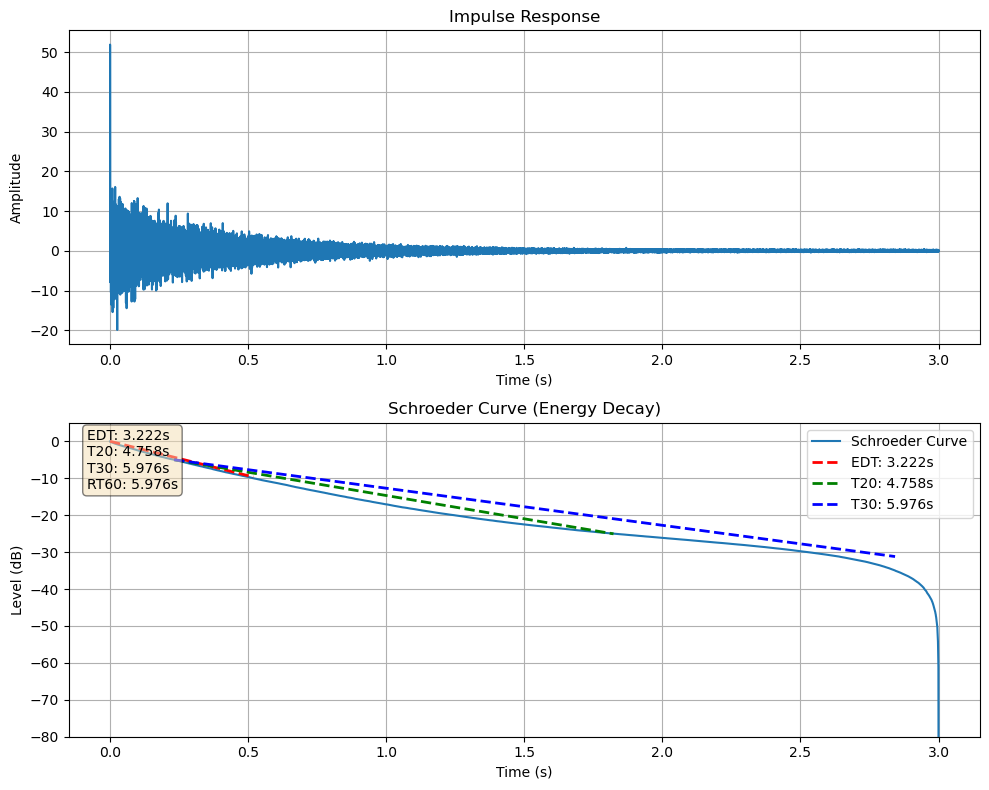

In [9]:
# plot
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot the impulse response
ax1.plot(t, h)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.set_title('Impulse Response')
ax1.grid(True)

# Plot the Schroeder curve
ax2.plot(res['t'], res['L_dB'], label='Schroeder Curve')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Level (dB)')
ax2.set_title('Schroeder Curve (Energy Decay)')
ax2.grid(True)
ax2.set_ylim([-80, 5])

# Plot fit lines for each RT measurement
colors = {'EDT': 'red', 'T20': 'green', 'T30': 'blue'}
for metric in ['EDT', 'T20', 'T30']:
    if np.isfinite(res[metric]):
        t_start, t_end = res['fit_intervals'][metric]
        slope = res['slope_dB_per_s'][metric]
        
        # Find the dB value at t_start to determine intercept
        idx_start = np.argmin(np.abs(res['t'] - t_start))
        L_start = res['L_dB'][idx_start]
        
        # Create fit line
        t_fit = np.array([t_start, t_end])
        L_fit = L_start + slope * (t_fit - t_start)
        
        ax2.plot(t_fit, L_fit, '--', color=colors[metric], linewidth=2, 
                label=f'{metric}: {res[metric]:.3f}s')

ax2.legend()

# Add RT60 measurements as text
textstr = f"EDT: {res['EDT']:.3f}s\nT20: {res['T20']:.3f}s\nT30: {res['T30']:.3f}s\nRT60: {res['RT60']:.3f}s"
ax2.text(0.02, 0.98, textstr, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()